In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


# See ATAC

In [3]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

union_peak_dir = os.path.join(Union_cell_subdir, "Union_cells_peaks")
atac_union_peak_pic = os.path.join(union_peak_dir, "DownstreamReanalysis", "bc_peak_pic_count.h5ad" )
h5_atac_union_peak = sc.read_h5ad(atac_union_peak_pic)
h5_atac_union_peak.obs['atac_barcodes'] = h5_atac_union_peak.obs['barcodes'].map(lambda x: x.split("-")[0])


In [4]:

col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_atac_union_peak.obs[col] = h5_atac_union_peak.obs['atac_barcodes'].map(union_cell_info[col])
    
h5_atac_union_peak.obs['log10_total_frag'] = np.log10(h5_atac_union_peak.obs['total_fragments'])


In [5]:

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# %%
PEAKVI_LATENT_KEY = "X_peakvi_Unionpeaks"
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_Unionpeaks"

#%%
# # filter regions with less than 3% of the cells
print("# regions before filtering:", h5_atac_union_peak.shape[-1])

sc.pp.filter_genes(h5_atac_union_peak, min_cells=10)
print("# regions after filtering:", h5_atac_union_peak.shape[-1])

# Let's Use All the identified peaks for comarison (since entropy approach already has more peaks)
# train on h5_atac_union_peak
scvi.model.PEAKVI.setup_anndata(h5_atac_union_peak)
peak_model = scvi.model.PEAKVI(h5_atac_union_peak)
peak_model.train()
# #save model
# peak_model.save(des_model_dir, overwrite=True)

# #save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_union_peak.obsm[PEAKVI_LATENT_KEY] = latent
resolution = 0.5
sc.pp.neighbors(h5_atac_union_peak, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_union_peak, min_dist=0.5)
sc.tl.leiden(h5_atac_union_peak, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)

Seed set to 0


Last run with scvi-tools version: 1.2.0
# regions before filtering: 39647


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/tmp/ipykernel_240464/3962595472.py:19: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precisio

# regions after filtering: 39591


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 164/500:  33%|███▎      | 164/500 [01:25<02:55,  1.92it/s, v_num=1, train_loss_step=8.29e+7, train_loss_epoch=1.37e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 9744.855. Signaling Trainer to stop.


/tmp/ipykernel_240464/3962595472.py:29: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_atac_union_peak, key_added=PEAKVI_CLUSTERS_KEY, resolution=resolution)


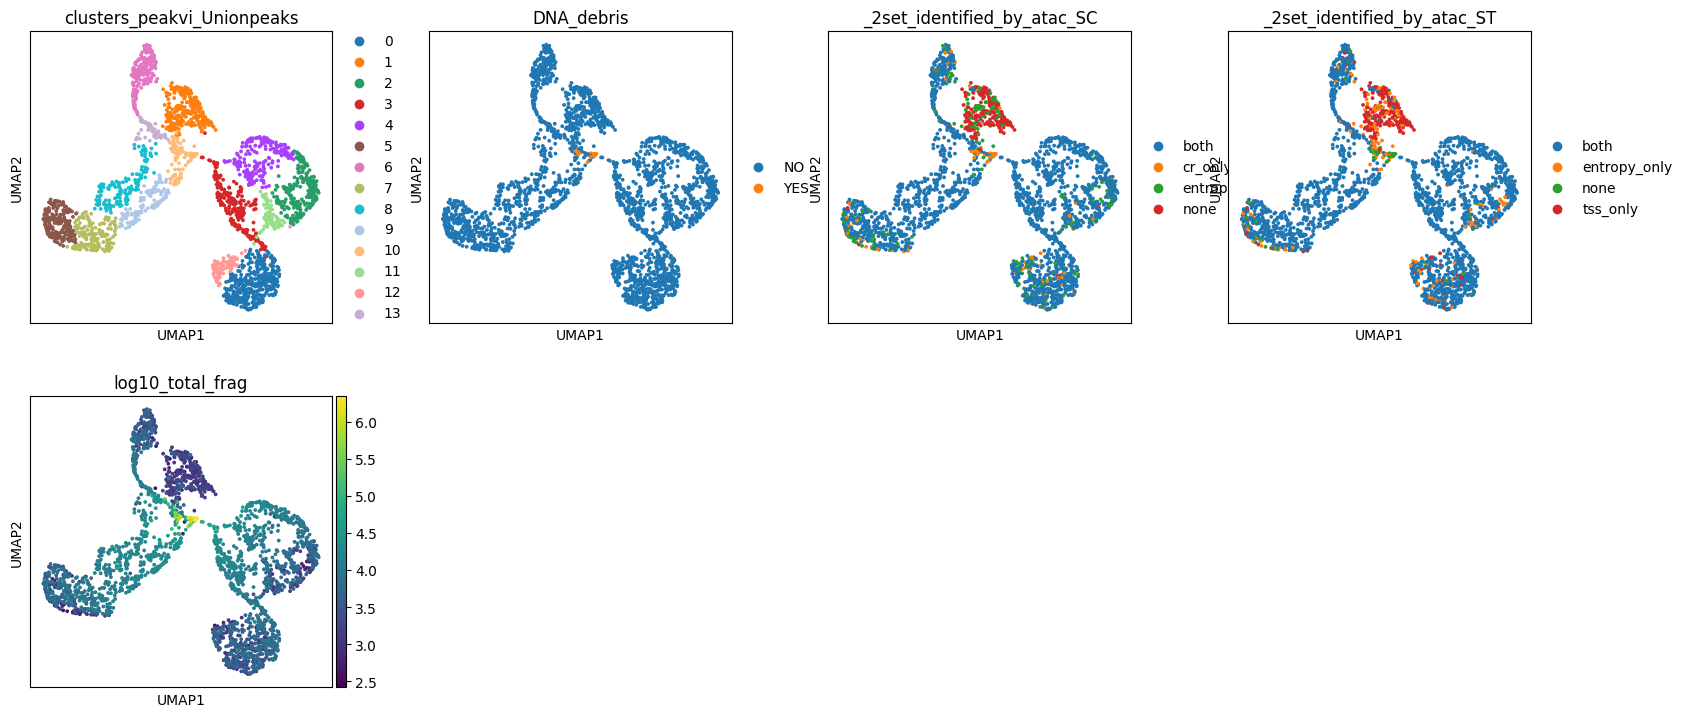

In [8]:

with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(h5_atac_union_peak, color=['clusters_peakvi_Unionpeaks', ] + 
               ['DNA_debris'] + 
                ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST'] + 
               ['log10_total_frag'], wspace=0.2, size=30, ncols=4)

In [14]:
h5_atac_union_peak.obs.groupby(['clusters_peakvi_Unionpeaks', 'DNA_debris']).size().unstack(fill_value=0)

/tmp/ipykernel_240464/3793951985.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_union_peak.obs.groupby(['clusters_peakvi_Unionpeaks', 'DNA_debris']).size().unstack(fill_value=0)


DNA_debris,NO,YES
clusters_peakvi_Unionpeaks,,
0,380,0
1,255,0
2,224,0
3,214,0
4,198,0
5,194,0
6,190,0
7,164,0
8,142,0


In [ ]:
h5_atac_union_peak.obs.groupby(['clusters_peakvi_Unionpeaks', 'DNA_debris']).size().unstack(fill_value=0)

## Check AMULET doublet 

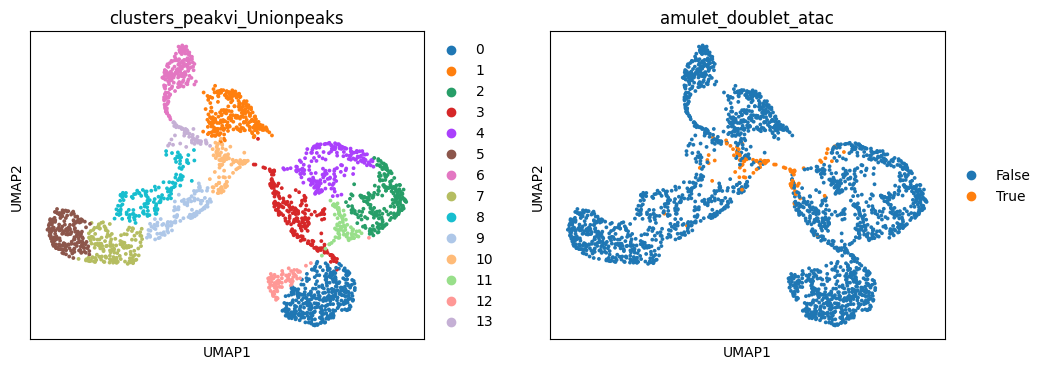

In [10]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)


h5_atac_union_peak.obs['amulet_doublet_atac'] = h5_atac_union_peak.obs['atac_barcodes'].isin(doublet_atac_barcodes['atac_bc'])

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_union_peak, color=['clusters_peakvi_Unionpeaks', 'amulet_doublet_atac'], wspace=0.2, size=30, ncols=2)

In [11]:
h5_atac_union_peak.obs.groupby(['atac_pass_CR', 'amulet_doublet_atac']).size().unstack(fill_value=0)

amulet_doublet_atac,False,True
atac_pass_CR,,
False,425,0
True,1863,96


In [12]:
h5_atac_union_peak.obs.groupby(['atac_pass_entropy', 'amulet_doublet_atac']).size().unstack(fill_value=0)

amulet_doublet_atac,False,True
atac_pass_entropy,,
False,263,20
True,2025,76


In [13]:
h5_atac_union_peak.obs.groupby(['atac_pass_archr_TSS', 'amulet_doublet_atac']).size().unstack(fill_value=0)

amulet_doublet_atac,False,True
atac_pass_archr_TSS,,
False,221,31
True,2067,65


In [15]:
h5_atac_union_peak.obs.groupby(['clusters_peakvi_Unionpeaks', 'amulet_doublet_atac']).size().unstack(fill_value=0)

/tmp/ipykernel_240464/2012086350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_atac_union_peak.obs.groupby(['clusters_peakvi_Unionpeaks', 'amulet_doublet_atac']).size().unstack(fill_value=0)


amulet_doublet_atac,False,True
clusters_peakvi_Unionpeaks,,
0,380,0
1,255,0
2,224,0
3,185,29
4,189,9
5,194,0
6,190,0
7,164,0
8,135,7


----

# -??

In [16]:
rna_col_list = ['MT%', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'leiden_RNA_scVI_unionBC']